kostya: пробую

In [2]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
data=csvFuturesSimData()
data

Configuring sim logging


csvFuturesSimData object with 252 instruments

In [1]:
from sysdata.sim.bybit_futures_sim_data import bybitFuturesSimData
data = bybitFuturesSimData()
data

Configuring sim logging


bybitFuturesSimData object with 3 instruments

In [ ]:
from sysdata.bybit import bybit_config

bybit_config.get_list_of_bybit_instruments()

['BTC_BYBIT', 'ETH_BYBIT', 'SOL_BYBIT']

In [2]:
data.get_instrument_list()

['BTC_BYBIT', 'ETH_BYBIT', 'SOL_BYBIT']

In [3]:
data.get_instrument_object_with_meta_data("BTC_BYBIT")

futuresInstrumentWithMetaData(instrument=BTC_BYBIT, meta_data={'Description': 'Bitcoin Perpetual ByBit', 'Pointsize': 0.001, 'Currency': 'USD', 'AssetClass': 'Crypto', 'PerBlock': 0.0, 'Percentage': 0.0008, 'PerTrade': 0, 'Region': 'ASIA'})

In [11]:
data.get_raw_price("BTC_BYBIT").tail(5)

2026-09-06 14:01:57 INFO bybitFuturesSimData {'component': 'bybitFuturesAdjustedPricesData', 'instrument_code': 'BTC_BYBIT'} Fetching adjusted prices for BTC_BYBIT (ByBit symbol: BTC/USDT:USDT)
2026-09-06 14:01:57 DEBUG ccxt.base.exchange GET https://api.bybit.com/v5/market/kline?symbol=BTCUSDT&start=1546300800000&limit=1000&interval=D&category=linear, Request: {'User-Agent': 'python-requests/2.34.2', 'Accept-Encoding': 'gzip, deflate', 'Accept': '*/*', 'Connection': 'keep-alive'} None
2026-09-06 14:01:57 DEBUG urllib3.connectionpool Resetting dropped connection: api.bybit.com


2026-09-06 14:01:58 DEBUG urllib3.connectionpool https://api.bybit.com:443 "GET /v5/market/kline?symbol=BTCUSDT&start=1546300800000&limit=1000&interval=D&category=linear HTTP/1.1" 200 87947
2026-09-06 14:01:58 DEBUG ccxt.base.exchange GET https://api.bybit.com/v5/market/kline?symbol=BTCUSDT&start=1546300800000&limit=1000&interval=D&category=linear, Response: 200 {'Content-Type': 'application/json', 'Content-Length': '87947', 'Connection': 'keep-alive', 'Date': 'Sun, 06 Sep 2026 06:01:58 GMT', 'Ret_code': '0', 'Traceid': '72947471d75413e737bd09b23404c1f5', 'Timenow': '1788674518209', 'Server': 'Openresty', 'x-cld-src': 'Loc-A', 'X-Cache': 'Miss from cloudfront', 'Via': '1.1 6bf2ca4ea5a5c92a1d7cd2f9767e8674.cloudfront.net (CloudFront)', 'X-Amz-Cf-Pop': 'FRA60-P3', 'X-Amz-Cf-Id': 'amsBqmxjHMV3b9GTLvAA6miaYhsAXqXBmIEDb2wuNDdbCJDsheqXlw=='} {"retCode":0,"retMsg":"OK","result":{"symbol":"BTCUSDT","category":"linear","list":[["1671408000000","16729.5","16805","16203","16432.5","106830.579","1

index
2026-09-02    77298.1
2026-09-03    81224.6
2026-09-04    79621.0
2026-09-05    79795.3
2026-09-06    79905.9
Name: FINAL, dtype: float64

In [5]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc


def calc_ewmac_forecast(price, Lfast, Lslow=None):
    """
    Calculate the ewmac trading rule forecast, given a price and EWMA speeds Lfast, Lslow and vol_lookback

    """
    ## price: This is the stitched price series
    ## We can't use the price of the contract we're trading, or the volatility will be jumpy
    ## And we'll miss out on the rolldown. See https://qoppac.blogspot.com/2015/05/systems-building-futures-rolling.html

    price = price.resample("1B").last()
    if Lslow is None:
        Lslow = 4 * Lfast

    ## We don't need to calculate the decay parameter, just use the span directly

    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma

    vol = robust_vol_calc(price.diff())

    return raw_ewmac / vol

2026-09-06 13:57:22 INFO bybitFuturesSimData {'component': 'bybitFuturesAdjustedPricesData', 'instrument_code': 'BTC_BYBIT'} Fetching adjusted prices for BTC_BYBIT (ByBit symbol: BTC/USDT:USDT)
2026-09-06 13:57:22 DEBUG ccxt.base.exchange GET https://api.bybit.com/v5/market/kline?symbol=BTCUSDT&start=1546300800000&limit=1000&interval=D&category=linear, Request: {'User-Agent': 'python-requests/2.34.2', 'Accept-Encoding': 'gzip, deflate', 'Accept': '*/*', 'Connection': 'keep-alive'} None


2026-09-06 13:57:22 DEBUG urllib3.connectionpool https://api.bybit.com:443 "GET /v5/market/kline?symbol=BTCUSDT&start=1546300800000&limit=1000&interval=D&category=linear HTTP/1.1" 200 None
2026-09-06 13:57:23 DEBUG ccxt.base.exchange GET https://api.bybit.com/v5/market/kline?symbol=BTCUSDT&start=1546300800000&limit=1000&interval=D&category=linear, Response: 200 {'Content-Type': 'application/json', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Date': 'Sun, 06 Sep 2026 05:57:22 GMT', 'content-encoding': 'gzip', 'vary': 'Accept-Encoding', 'Ret_code': '0', 'Traceid': '135633716f7c45db2ad7ae38d9769930', 'Timenow': '1788674242845', 'Server': 'Openresty', 'x-cld-src': 'Loc-A', 'X-Cache': 'Miss from cloudfront', 'Via': '1.1 1232ef1832a7212470cbe45556a02b9a.cloudfront.net (CloudFront)', 'X-Amz-Cf-Pop': 'WAW51-P3', 'X-Amz-Cf-Id': 'Z6UZ12J3F1XTo2iHbM4CRVo_UnombJuuPLf55ZS2yKhc0BQbTciI3w=='} {"retCode":0,"retMsg":"OK","result":{"symbol":"BTCUSDT","category":"linear","list":[["1671408

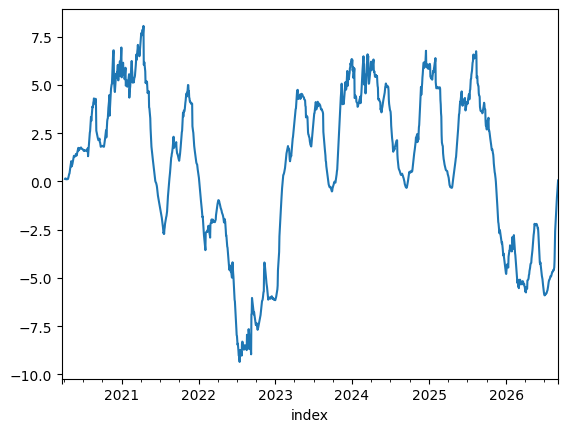

In [8]:
instrument_code='BTC_BYBIT'
price=data.daily_prices(instrument_code)
ewmac=calc_ewmac_forecast(price, 32, 128)
ewmac.tail(5)

from matplotlib.pyplot import show
ewmac.plot()
show()

In [9]:
from systems.accounts.account_forecast import pandl_for_instrument_forecast
account = pandl_for_instrument_forecast(forecast = ewmac, price=price)
account.percent.stats()

[[('min', '-2.88'),
  ('max', '2.996'),
  ('median', '0.001998'),
  ('mean', '0.01419'),
  ('std', '0.4579'),
  ('skew', '0.1165'),
  ('ann_mean', '3.633'),
  ('ann_std', '7.327'),
  ('sharpe', '0.4958'),
  ('sortino', '0.6335'),
  ('avg_drawdown', '-5.112'),
  ('time_in_drawdown', '0.9602'),
  ('calmar', '0.3025'),
  ('avg_return_to_drawdown', '0.7107'),
  ('avg_loss', '-0.2743'),
  ('avg_gain', '0.2871'),
  ('gaintolossratio', '1.047'),
  ('profitfactor', '1.107'),
  ('hitrate', '0.5141'),
  ('t_stat', '1.271'),
  ('p_value', '0.2038')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

3.6328630594464495

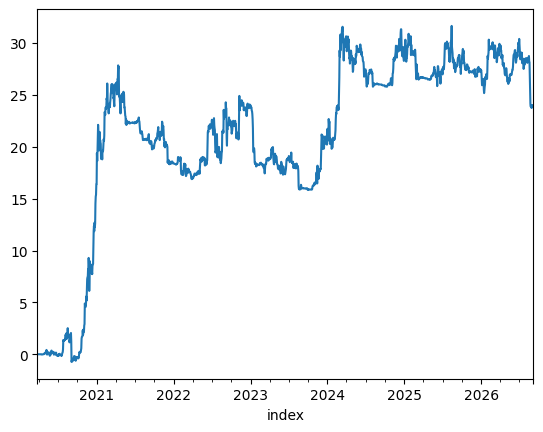

In [10]:
import syscore.pandas.strategy_functions

account.sharpe()  ## get the Sharpe Ratio (annualised), and any other statistic which is in the stats list
account.curve().plot()  ## plot the cumulative account curve (equivalent to account.cumsum().plot() inicidentally)
account.percent  ## gives a % curve
#syscore.pandas.strategy_functions.drawdown().plot()  ## see the drawdowns as a percentage
account.weekly  ## weekly returns (also daily [default], monthly, annual)
account.gross.ann_mean()  ## annual mean for gross returns, also costs (there are none in this simple example)